100%|██████████| 12000/12000 [00:00<00:00, 183954.65it/s]


Visualizing sample 0


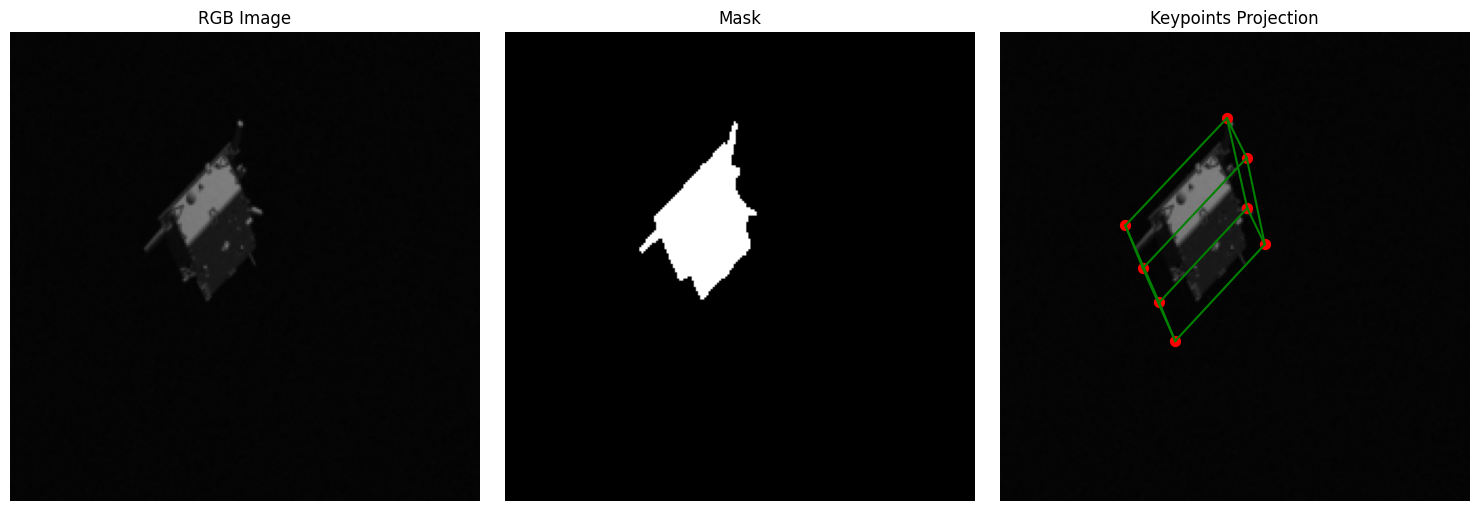

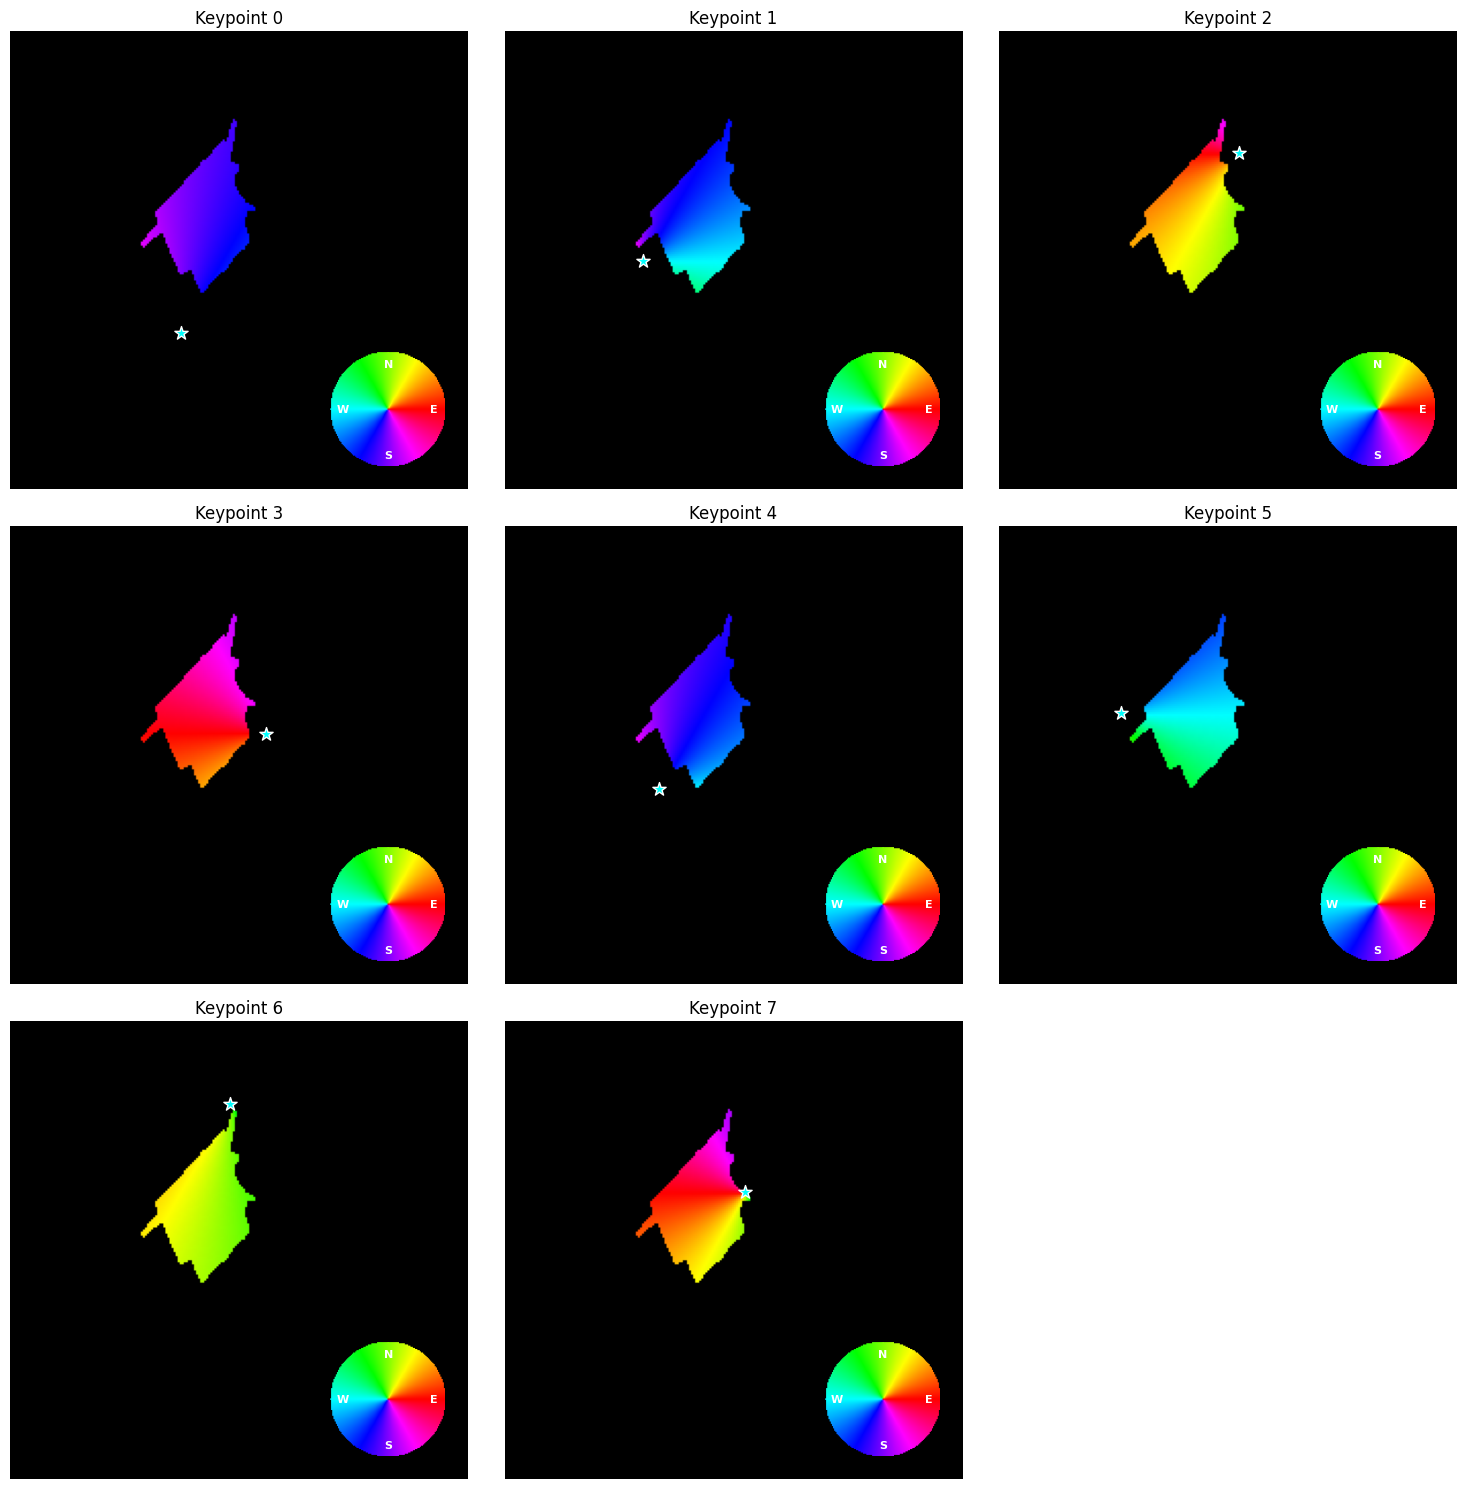

/tmp/ipykernel_19/2191584251.py:687: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Epoch 1 

/usr/local/lib/python3.11/dist-packages/torch/nn/_reduction.py:51: UserWarning: size_average and reduce args will be deprecated, please use reduction='none' instead.
  warnings.warn(warning.format(ret))


Epoch 1 : Training loss: 0.459068 - Validation loss: 0.299567                                         
Epoch 2 : Training loss: 0.280823 - Validation loss: 0.268359                                         
Epoch 3 : Training loss: 0.264019 - Validation loss: 0.259346                                         
Epoch 4 : Training loss: 0.255392 - Validation loss: 0.258084                                         
Epoch 5 : Training loss: 0.246569 - Validation loss: 0.246224                                         
Epoch 6 : Training loss: 0.236097 - Validation loss: 0.241680                                         
Epoch 7 : Training loss: 0.225262 - Validation loss: 0.232015                                         
Epoch 8 : Training loss: 0.213515 - Validation loss: 0.227919                                         
Epoch 9 : Training loss: 0.202740 - Validation loss: 0.222987                                         
Epoch 10 : Training loss: 0.193430 - Validation loss: 0.215534           

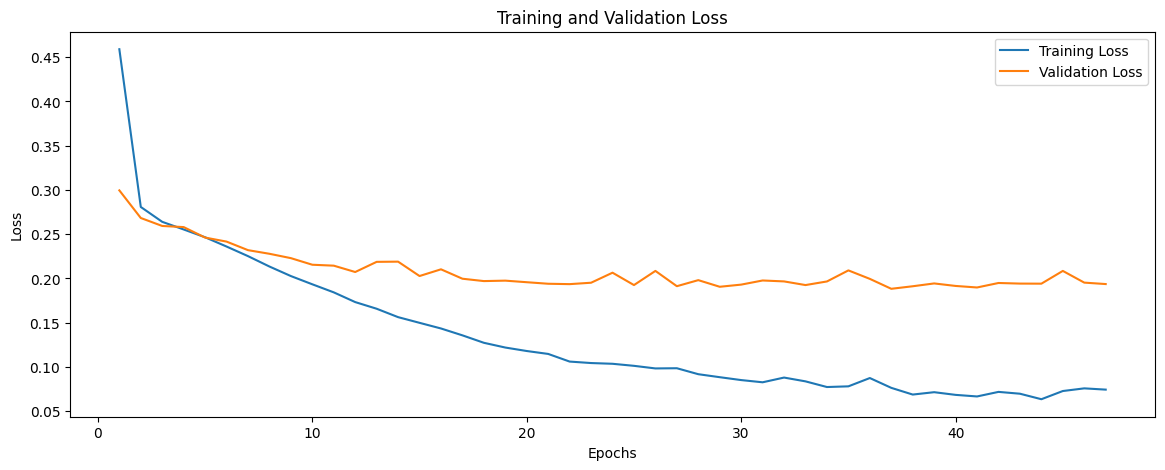

In [1]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn,optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchinfo import summary
from scipy.io import loadmat
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import numpy as np
import tqdm
import torch.utils.model_zoo as model_zoo
import math
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import hsv_to_rgb

def quat2dcm(q):
    """ Computing direction cosine matrix from quaternion, adapted from PyNav.
    Arguments:
        q: (4,) numpy.ndarray - unit quaternion (scalar-first)
    Returns:
        dcm: (3,3) numpy.ndarray - corresponding DCM
    """

    # normalizing quaternion
    q = q/np.linalg.norm(q)

    q0 = q[0]
    q1 = q[1]
    q2 = q[2]
    q3 = q[3]

    dcm = np.zeros((3, 3))

    dcm[0, 0] = 2 * q0 ** 2 - 1 + 2 * q1 ** 2
    dcm[1, 1] = 2 * q0 ** 2 - 1 + 2 * q2 ** 2
    dcm[2, 2] = 2 * q0 ** 2 - 1 + 2 * q3 ** 2

    dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
    dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2

    dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
    dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1

    dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
    dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1

    return dcm

def get_3d_bbox(keypts_3d):
    """
    Compute a 3D bounding box (cuboid) that encloses the given keypoints.
    
    Args:
        keypts_3d: numpy array of shape (N, 3) where N is the number of keypoints
    
    Returns:
        bbox: numpy array of shape (8, 3) representing the corners of the 3D bounding box
    """
    # Find min and max values for each dimension
    min_vals = np.min(keypts_3d, axis=0)
    max_vals = np.max(keypts_3d, axis=0)
    
    # Create the 8 corners of the bounding box
    bbox = np.array([
        [min_vals[0], min_vals[1], min_vals[2]],  # 0: min_x, min_y, min_z
        [max_vals[0], min_vals[1], min_vals[2]],  # 1: max_x, min_y, min_z
        [max_vals[0], max_vals[1], min_vals[2]],  # 2: max_x, max_y, min_z
        [min_vals[0], max_vals[1], min_vals[2]],  # 3: min_x, max_y, min_z
        [min_vals[0], min_vals[1], max_vals[2]],  # 4: min_x, min_y, max_z
        [max_vals[0], min_vals[1], max_vals[2]],  # 5: max_x, min_y, max_z
        [max_vals[0], max_vals[1], max_vals[2]],  # 6: max_x, max_y, max_z
        [min_vals[0], max_vals[1], max_vals[2]]   # 7: min_x, max_y, max_z
    ])
    
    return bbox
    
def get_data_pts_2d(pts_3d, RT, cam_K):
    pts_2d=np.matmul(pts_3d,RT[:,:3].T)+RT[:,3:].T
    pts_2d=np.matmul(pts_2d,cam_K.T)
    pts_2d=pts_2d[:,:2]/pts_2d[:,2:]
    return pts_2d

def compute_vertex_hcoords(mask, hcoords, use_motion=False):
    h,w=mask.shape
    m=hcoords.shape[0]
    xy = np.argwhere(mask == 1)[:, [1, 0]]
    vertex = xy[:, None, :]*hcoords[None, :, 2:]
    vertex = hcoords[None, :, :2] - vertex
    if not use_motion:
        norm = np.linalg.norm(vertex, axis=2, keepdims=True)
        norm[norm<1e-3] += 1e-3
        vertex = vertex / norm

    vertex_out=np.zeros([h,w,m,2],np.float32)
    vertex_out[xy[:, 1], xy[:, 0]] = vertex
    return  np.reshape(vertex_out,[h,w,m*2])

def smooth_l1_loss(vertex_pred, vertex_targets, vertex_weights, sigma=1.0, normalize=True, reduce=True):
    '''
    :param vertex_pred:     [b,vn*2,h,w]
    :param vertex_targets:  [b,vn*2,h,w]
    :param vertex_weights:  [b,1,h,w]
    :param sigma:
    :param normalize:
    :param reduce:
    :return:
    '''
    b,ver_dim,_,_=vertex_pred.shape
    sigma_2 = sigma ** 2
    vertex_diff = vertex_pred - vertex_targets
    diff = vertex_weights * vertex_diff
    abs_diff = torch.abs(diff)
    smoothL1_sign = (abs_diff < 1. / sigma_2).detach().float()
    in_loss = torch.pow(diff, 2) * (sigma_2 / 2.) * smoothL1_sign \
              + (abs_diff - (0.5 / sigma_2)) * (1. - smoothL1_sign)

    if normalize:
        in_loss=torch.sum(in_loss.view(b,-1),1) / (ver_dim * torch.sum(vertex_weights.view(b,-1),1) + 1e-3)

    if reduce:
       torch.mean(in_loss)

    return in_loss

def load_tango_3d_keypoints(mat_dir):
    vertices  = loadmat(mat_dir)['tango3Dpoints'] # [3 x 11]
    corners3D = np.transpose(np.array(vertices, dtype=np.float32)) # [11 x 3]

    return corners3D

def load_camera_intrinsics(camera_json):
    with open(camera_json) as f:
        cam = json.load(f)
    cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
    distCoeffs   = np.array(cam['distCoeffs'],   dtype=np.float32)

    return cameraMatrix, distCoeffs

def project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
    ''' Project keypoints.
    Arguments:
        q_vbs2tango:  (4,) numpy.ndarray - unit quaternion from VBS to Tango frame
        r_Vo2To_vbs:  (3,) numpy.ndarray - position vector from VBS to Tango in VBS frame (m)
        cameraMatrix: (3,3) numpy.ndarray - camera intrinsics matrix
        distCoeffs:   (5,) numpy.ndarray - camera distortion coefficients in OpenCV convention
        keypoints:    (3,N) or (N,3) numpy.ndarray - 3D keypoint locations (m)
    Returns:
        points2D: (2,N) numpy.ndarray - projected points (pix)
    '''
    # Size check (3,N)
    if keypoints.shape[0] != 3:
        keypoints = np.transpose(keypoints)

    # Keypoints into 4 x N homogenous coordinates
    keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))

    # transformation to image frame
    pose_mat = np.hstack((np.transpose(quat2dcm(q_vbs2tango)),
                          np.expand_dims(r_Vo2To_vbs, 1)))
    xyz      = np.dot(pose_mat, keypoints) # [3 x N]
    x0, y0   = xyz[0,:] / xyz[2,:], xyz[1,:] / xyz[2,:] # [1 x N] each

    # apply distortion
    r2 = x0*x0 + y0*y0
    cdist = 1 + distCoeffs[0]*r2 + distCoeffs[1]*r2*r2 + distCoeffs[4]*r2*r2*r2
    x  = x0*cdist + distCoeffs[2]*2*x0*y0 + distCoeffs[3]*(r2 + 2*x0*x0)
    y  = y0*cdist + distCoeffs[2]*(r2 + 2*y0*y0) + distCoeffs[3]*2*x0*y0

    # apply camera matrix
    points2D = np.vstack((cameraMatrix[0,0]*x + cameraMatrix[0,2],
                          cameraMatrix[1,1]*y + cameraMatrix[1,2]))

    return points2D

def visualize_object_with_bbox(rgb_img, mask, hcoords, figsize=(15, 5)):
    """Visualize RGB, mask, and projected keypoints"""
    plt.figure(figsize=figsize)
    
    plt.subplot(1, 3, 1)
    plt.imshow(rgb_img)
    plt.title('RGB Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Mask')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(rgb_img)
    plt.title('Keypoints Projection')
    
    points_2d = hcoords[:, :2].numpy()
    
    segments = {
        'top_square': [(0, 1), (1, 2), (2, 3), (3, 0)],  # Top square
        'vertical': [(0, 4), (1, 5), (2, 6), (3, 7)],     # Vertical connections
        'base_square': [(4, 5), (5, 6), (6, 7), (7, 4)],   # Base square
        'antenna': [(1, 8), (2, 9), (3, 10)]              # Antenna connections
    }
    
    segment_colors = {
        'base_square': 'g',   # Blue
        'vertical': 'g',      # Green
        'top_square': 'g',    # Cyan 
        'antenna': 'g'        # Magenta
    }
    
    for seg_type, connections in segments.items():
        color = segment_colors[seg_type]
        for p1_idx, p2_idx in connections:
            if p1_idx < len(points_2d) and p2_idx < len(points_2d):
                plt.plot([points_2d[p1_idx, 0], points_2d[p2_idx, 0]],
                         [points_2d[p1_idx, 1], points_2d[p2_idx, 1]],
                         f'{color}-', linewidth=1.5, label=seg_type if connections.index((p1_idx, p2_idx)) == 0 else "")
    
    plt.scatter(points_2d[:, 0], points_2d[:, 1], c='r', s=50)
    
    
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()



class SPEEDDataset(Dataset):
    def __init__(self, images_dir, json_dir, mask_dir, transform=None):
        self.transform = transform

        self.rgbPthList = []
        self.maskPthList = []
        self.frameInfoList = []
        self.images_dir = images_dir
        self.json_dir = json_dir
        self.mask_dir = mask_dir

        with open(self.json_dir, 'r') as f:
            annotations = json.load(f)
            lookup = { item['filename']: item for item in annotations }

            cnt = 0
            for filename in tqdm.tqdm(sorted(os.listdir(self.images_dir))):
                if filename not in lookup:
                    continue
                
                frame_idx = int(''.join(filter(str.isdigit, filename.split('.')[0])))

                pngFilename = filename.replace('.jpg', '.png')
                
                self.rgbPthList.append(os.path.join(self.images_dir, filename))
                self.maskPthList.append(os.path.join(self.mask_dir, pngFilename))

                q_vbs2tango = np.array(lookup[filename]["q_vbs2tango"], dtype=np.float32)
                r_Vo2To_vbs = np.array(lookup[filename]['r_Vo2To_vbs_true'], dtype=np.float32)

                frame_info = {
                    'frame_idx': frame_idx,
                    'q_vbs2tango': q_vbs2tango,
                    'r_Vo2To_vbs': r_Vo2To_vbs
                }
                self.frameInfoList.append(frame_info)

                cnt = cnt + 1
                # if cnt>10:
                #     break

    def __len__(self):
        return len(self.rgbPthList)

    def __getitem__(self, idx):
        rgb_path = self.rgbPthList[idx]
        rgb_img = Image.open(rgb_path).convert('RGB')
        rgb_img = np.array(rgb_img)
        rgb = torch.from_numpy(rgb_img).float().permute(2, 0, 1)
        
        mask_path = self.maskPthList[idx]
        mask_img = Image.open(mask_path).convert('1')
        mask_seg = np.array(mask_img).astype(np.int32)
        mask = torch.from_numpy(mask_seg).long()
        
        frame_info = self.frameInfoList[idx]
        keypts3d = load_tango_3d_keypoints('/kaggle/input/mat-file/tangoPoints.mat') # https://www.desmos.com/3d/jud6lng9gn
        pts_3dbbox = get_3d_bbox(keypts3d)
        cameraMatrix, distCoeffs = load_camera_intrinsics('/kaggle/input/mat-file/camera.json')
        
        keypts2d = project_keypoints(frame_info['q_vbs2tango'], frame_info['r_Vo2To_vbs'], cameraMatrix, distCoeffs, pts_3dbbox).T # (8, 2)
        hcoords = np.concatenate([keypts2d, np.ones([8, 1], np.float32)], 1)
        
        orig_h, orig_w = mask_seg.shape
        
        rotation_matrix = quat2dcm(frame_info['q_vbs2tango'])
        translation_vector = frame_info['r_Vo2To_vbs'].reshape(3, 1)
        RT = np.hstack((rotation_matrix, translation_vector))
        
        if self.transform:
            rgb = self.transform(rgb)
            mask = self.transform(mask.unsqueeze(0)).squeeze(0)
            
            new_h, new_w = mask.shape
            
            scale_x = new_w / orig_w
            scale_y = new_h / orig_h

            scaled_keypts2d = keypts2d.copy()
            scaled_keypts2d[:, 0] *= scale_x
            scaled_keypts2d[:, 1] *= scale_y
            
            scaled_hcoords = hcoords.copy()
            scaled_hcoords[:, 0] *= scale_x
            scaled_hcoords[:, 1] *= scale_y
            
            mask_np = mask.numpy().astype(np.int32)
            ver_np = compute_vertex_hcoords(mask_np, scaled_hcoords, use_motion=False)
            hcoords = torch.tensor(scaled_hcoords.astype(np.float32))
        else:
            ver_np = compute_vertex_hcoords(mask_seg, hcoords, use_motion=False)
            hcoords = torch.tensor(hcoords.astype(np.float32))
            
        ver = torch.tensor(ver_np, dtype=torch.float32).permute(2, 0, 1)
        ver_weight = mask.unsqueeze(0).float()
        pose = torch.tensor(RT.astype(np.float32))

        return rgb, mask, ver, ver_weight, pose, hcoords
    
transform = transforms.Compose([
        transforms.Resize((224, 224)),
    ])

dataset = SPEEDDataset(images_dir='/kaggle/input/speedsplit/speed/images/trainval', json_dir='/kaggle/input/speedsplit/speed/train.json', mask_dir= '/kaggle/input/speedsplitmaskssamvit-h/speedsplit/speed/masks/trainval' ,transform=transform)
train_size= int(0.8* len(dataset))
train_data, val_data = random_split(dataset, [train_size, len(dataset) - train_size])

num_images = min(1,len(dataset))
for idx in range(num_images):
    print(f"Visualizing sample {idx}")
    rgb_sample, mask_sample, ver_sample, ver_weight_sample, pose_sample, hcoords_sample = dataset[idx]
    rgb_np = rgb_sample.permute(1, 2, 0).numpy().astype(np.uint8)
    mask_np = mask_sample.numpy()
    
    visualize_object_with_bbox(rgb_np, mask_np, hcoords_sample)

def visualize_vertex(vertex, vertex_weights, keypoints=None):
    """
    Visualize vertex vectors with directional coloring on a black background.
    Also plots the keypoints locations if provided.
    
    Args:
        vertex: Vertex vectors [batch, channels, height, width]
        vertex_weights: Vertex weights [batch, 1, height, width]
        keypoints: Optional keypoints to plot [8, 3] (hcoords)
    """
    
    
    # Apply weights to vertex
    vertex = vertex * vertex_weights
    
    # Changed to 3x3 grid to accommodate 8 keypoints
    plt.figure(figsize=(15, 15))
    n_keypoints = vertex.shape[1] // 2

    # Create directional images for each keypoint
    for i in range(n_keypoints):
        ax = plt.subplot(3, 3, i+1)
        
        # Get x and y components
        vx = vertex[0, 2*i].cpu().numpy()
        vy = vertex[0, 2*i+1].cpu().numpy()
        
        # Calculate angle and magnitude
        angle = np.arctan2(vy, vx)
        magnitude = np.sqrt(vx**2 + vy**2)
        
        # Create HSV image
        h, w = vx.shape
        hsv_img = np.zeros((h, w, 3))
        
        # Calculate normalized angle (hue), but flip the angle to match the legend
        # This ensures colors in the visualization match the direction legend
        hsv_img[:, :, 0] = ((-angle + 2*np.pi) % (2*np.pi)) / (2*np.pi)  # Hue from angle
        hsv_img[:, :, 1] = 1.0  # Full saturation
        
        # Get mask of valid pixels
        mask = vertex_weights[0, 0].cpu().numpy() > 0
        
        # Set value channel (brightness)
        hsv_img[:, :, 2] = np.zeros_like(magnitude)  # Black background
        if mask.any() and magnitude[mask].max() > 0:
            hsv_img[:, :, 2][mask] = np.clip(magnitude[mask] / magnitude[mask].max(), 0, 1)
        
        # Convert to RGB
        rgb_img = hsv_to_rgb(hsv_img)
        
        plt.imshow(rgb_img)
        
        # Plot keypoint if provided
        if keypoints is not None and i < len(keypoints):
            kp_x, kp_y = int(keypoints[i, 0]), int(keypoints[i, 1])
            if 0 <= kp_x < w and 0 <= kp_y < h:
                plt.scatter(kp_x, kp_y, c='cyan', s=100, marker='*', edgecolors='white')
        
        plt.title(f'Keypoint {i}')
        plt.axis('off')

        # Add inset legend to the bottom right
        ax_inset = ax.inset_axes([0.7, 0.05, 0.25, 0.25])
        
        # Generate a color wheel
        size = 100
        center = size // 2
        y, x = np.ogrid[:size, :size]
        dist = np.sqrt((x - center)**2 + (y - center)**2)
        
        # Create a circular mask
        mask_wheel = dist <= center
        
        # Generate the color wheel
        angles = np.arctan2(center - y, x - center)
        hues = ((angles + 2*np.pi) % (2*np.pi)) / (2*np.pi)
        
        # Create HSV image
        hsv_wheel = np.zeros((size, size, 3))
        hsv_wheel[:, :, 0] = hues
        hsv_wheel[:, :, 1] = 1.0 # Use full saturation for simplicity
        hsv_wheel[:, :, 2] = mask_wheel.astype(float)
        
        # Convert to RGB
        rgb_wheel = hsv_to_rgb(hsv_wheel)
        
        ax_inset.imshow(rgb_wheel)
        ax_inset.axis('off')
        
        # Add direction labels
        directions = ['E', 'N', 'W', 'S']
        angles_text = [0, np.pi/2, np.pi, 3*np.pi/2]
        radius = center * 0.8
        
        for angle_text, direction in zip(angles_text, directions):
            x_t = center + radius * np.cos(angle_text)
            y_t = center - radius * np.sin(angle_text)
            ax_inset.text(x_t, y_t, direction, ha='center', va='center', 
                    color='white', fontweight='bold', fontsize=8)
    
    plt.tight_layout()
    plt.show()

rgb_sample, mask_sample, ver_sample, ver_weight_sample, pose_sample, hcoords_sample = dataset[0]

ver_sample = ver_sample.unsqueeze(0) 
ver_weight_sample = ver_weight_sample.unsqueeze(0)  

visualize_vertex(ver_sample, ver_weight_sample, hcoords_sample)

class AlexNetBackbone(nn.Module):
    def __init__(self, pretrained=True):
        super(AlexNetBackbone, self).__init__()
        
        # 1st Layer: Conv (w ReLu) -> Pool -> Lrn
        self.conv1 = nn.Conv2d(3, 96, kernel_size=11, stride=4, padding=0)
        self.relu1 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(3, stride=2, padding=0)
        self.norm1 = nn.LocalResponseNorm(2, alpha=2e-5, beta=0.75, k=1.0)

        # 2nd Layer: Conv (w ReLu) -> Pool -> Lrn with 2 groups
        self.conv2 = nn.Conv2d(96, 256, kernel_size=5, stride=1, padding=2, groups=2)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(3, stride=2, padding=0)
        self.norm2 = nn.LocalResponseNorm(2, alpha=2e-5, beta=0.75, k=1.0)

        # 3rd Layer: Conv (w ReLU)
        self.conv3 = nn.Conv2d(256, 384, kernel_size=3, stride=1, padding=1)
        self.relu3 = nn.ReLU(inplace=True)

        # 4th Layer: Conv (w ReLu) splitted into two groups
        self.conv4 = nn.Conv2d(384, 384, kernel_size=3, stride=1, padding=1, groups=2)
        self.relu4 = nn.ReLU(inplace=True)

        # 5th Layer: Conv (w ReLu) -> Pool splitted into two groups
        self.conv5 = nn.Conv2d(384, 256, kernel_size=3, stride=1, padding=1, groups=2)
        self.relu5 = nn.ReLU(inplace=True)
        self.pool5 = nn.MaxPool2d(3, stride=2, padding=0)
        
        # Final projection - similar to FC layer in the original architecture
        self.fc = nn.Conv2d(256, 256, kernel_size=1)
        
        if pretrained:
            self.load_weights('/kaggle/input/bvlc-alexnet-zeiler-and-fergus/bvlc_alexnet.npy')

    def load_weights(self, weight_path):
        # Load weight dict
        weights_dict = np.load(weight_path, allow_pickle=True, encoding='bytes').item()

        # Only load weights for the first 5 layers
        with torch.no_grad():
            for name in weights_dict:
                if name in ['conv1', 'conv2', 'conv3', 'conv4', 'conv5']:
                    for data in weights_dict[name]:
                        if len(data.shape) == 4:
                            # [H, W, Cin, Cout] -> [Cout, Cin, H, W]
                            data = np.transpose(data, (3,2,0,1))
                            getattr(self, name).weight.copy_(torch.from_numpy(data).float())
                        else:
                            getattr(self, name).bias.copy_(torch.from_numpy(data).float())

    def forward(self, x):
         # Store features at different levels for feature pyramid
        x1 = self.conv1(x)
        x1 = self.relu1(x1)
        
        x2s = x1  # First scale feature
        
        x1 = self.pool1(x1)
        x1 = self.norm1(x1)
        
        x1 = self.conv2(x1)
        x1 = self.relu2(x1)
        
        x4s = x1  # Second scale feature
        
        x1 = self.pool2(x1)
        x1 = self.norm2(x1)
        
        x1 = self.conv3(x1)
        x1 = self.relu3(x1)
        
        x1 = self.conv4(x1)
        x1 = self.relu4(x1)
        
        x8s = x1  # Third scale feature
        
        x1 = self.conv5(x1)
        x1 = self.relu5(x1)

        x16s = x1  # Fourth scale feature
        
        x1 = self.pool5(x1)
        
        x32s = x1  # Fifth scale feature
        
        xfc = self.fc(x1)  # Final feature
        
        return x2s, x4s, x8s, x16s, x32s, xfc
        
class AlexNet8s(nn.Module):
    def __init__(self, ver_dim, seg_dim, fcdim=256, s8dim=128, s4dim=64, s2dim=32, raw_dim=32):
        super(AlexNet8s, self).__init__()

        self.ver_dim = ver_dim
        self.seg_dim = seg_dim
        
        self.alexnet_backbone = AlexNetBackbone()
        
        self.upfc_to_8s = nn.UpsamplingBilinear2d(scale_factor=2.4) 

        # x8s->128
        self.conv8s = nn.Sequential(
            nn.Conv2d(256+384, s8dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(s8dim),
            nn.LeakyReLU(0.1, True)
        )
        self.up8sto4s = nn.UpsamplingBilinear2d(scale_factor=2)

        # x4s->64
        self.conv4s = nn.Sequential(
            nn.Conv2d(256+s8dim, s4dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(s4dim),
            nn.LeakyReLU(0.1, True)
        )
        self.up4sto2s = nn.UpsamplingBilinear2d(scale_factor=2)

        # x2s->64 - adjust input dimension to match alexnet's first layer output (96)
        self.conv2s = nn.Sequential(
            nn.Conv2d(96+s4dim, s2dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(s2dim),
            nn.LeakyReLU(0.1, True)
        )
        self.up2storaw = nn.UpsamplingBilinear2d(scale_factor=4)  # Increased scale factor to match dimensions

        self.convraw = nn.Sequential(
            nn.Conv2d(3+s2dim, raw_dim, 3, 1, 1, bias=False),
            nn.BatchNorm2d(raw_dim),
            nn.LeakyReLU(0.1, True),
            nn.Conv2d(raw_dim, seg_dim+ver_dim, 1, 1)
        )

    def forward(self, x, feature_alignment=False):
        # Get features from AlexNet backbone
        x2s, x4s, x8s, x16s, x32s, xfc = self.alexnet_backbone(x)

        # Use adaptive interpolation instead of fixed scale factor
        xfc_upsampled = nn.functional.interpolate(
            xfc, 
            size=(x8s.size(2), x8s.size(3)), 
            mode='bilinear', 
            align_corners=False
        )
        
        fm = self.conv8s(torch.cat([xfc_upsampled, x8s], 1))
        
        # Resize feature map to match x4s dimensions
        fm = nn.functional.interpolate(
            fm, 
            size=(x4s.size(2), x4s.size(3)), 
            mode='bilinear', 
            align_corners=False
        )

        fm = self.conv4s(torch.cat([fm, x4s], 1))
        
        # Resize feature map to match x2s dimensions
        fm = nn.functional.interpolate(
            fm, 
            size=(x2s.size(2), x2s.size(3)), 
            mode='bilinear', 
            align_corners=False
        )

        fm = self.conv2s(torch.cat([fm, x2s], 1))
        
        # Resize feature map to match input dimensions
        fm = nn.functional.interpolate(
            fm, 
            size=(x.size(2), x.size(3)), 
            mode='bilinear', 
            align_corners=False
        )

        x = self.convraw(torch.cat([fm, x], 1))
        seg_pred = x[:, :self.seg_dim, :, :]
        ver_pred = x[:, self.seg_dim:, :, :]

        return seg_pred, ver_pred

def train_loop(train_dataloader,val_dataloader,model,loss_fn,optimizer,batch_size,epoch):
    train_size = len(train_dataloader.dataset)
    num_batches = len(train_dataloader)
    loss_tot = 0
    for batch,(X, yMask, yVer, yVerWeight, yPose, yHcoords ) in enumerate(train_dataloader):
        X, yMask, yVer, yVerWeight, yPose, yHcoords = X.to(device), yMask.to(device), yVer.to(device), yVerWeight.to(device), yPose.to(device), yHcoords.to(device)
        model.train()
        optimizer.zero_grad()

        with autocast("cuda"):
            seg_pred, ver_pred = model(X)
            loss_seg = loss_fn(seg_pred, yMask)
            loss_seg = torch.mean(loss_seg.view(loss_seg.shape[0],-1),1)
            loss_ver = smooth_l1_loss(ver_pred, yVer, yVerWeight, reduce=False)
            loss = torch.mean(loss_seg + 1.0 * loss_ver)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        loss_tot += loss.item()

        current = batch * batch_size + len(X)
        print(f"\rEpoch {epoch+1} : Training loss: {loss:>7f}  [{current:>5d}/{train_size:>5d}]", end="")

    # scheduler.step()  
    loss_avg = loss_tot / num_batches
    val_loss = 0
    model.eval()
    with torch.no_grad():
        for batch, (X, yMask, yVer, yVerWeight, yPose, yHcoords) in enumerate(val_dataloader):
            X, yMask, yVer, yVerWeight, yPose, yHcoords = X.to(device), yMask.to(device), yVer.to(device), yVerWeight.to(device), yPose.to(device), yHcoords.to(device)
            with autocast("cuda"):
                seg_pred, ver_pred = model(X)
            loss_seg = loss_fn(seg_pred, yMask)
            loss_seg = torch.mean(loss_seg.view(loss_seg.shape[0], -1), 1)
            loss_ver = smooth_l1_loss(ver_pred, yVer, yVerWeight, reduce=False)
            loss = torch.mean(loss_seg + 1.0 * loss_ver).item()
            val_loss += loss
            current = batch * batch_size + len(X)
            print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Validation loss: {loss:>7f}  [{batch * batch_size + len(X):>5d}/{len(val_dataloader.dataset):>5d}]", end="")

    val_loss /= len(val_dataloader)
    print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Validation loss: {val_loss:>7f}                                         ")
    print(end='')
    return loss_avg, val_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler = GradScaler()
model = AlexNet8s(ver_dim=8 * 2, seg_dim=2).to(device)

learning_rate = 1e-3
batch_size = 32
epochs = 50
loss_fn = nn.CrossEntropyLoss(reduce=False)

optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.50)

train_dataloader = DataLoader(train_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)
validation_dataloader = DataLoader(val_data, batch_size, shuffle=True, num_workers=4, pin_memory=True)

# print(summary(model, (1,3,224,224)))

loss_history = {'train': [], 'val': []}

best_val_loss = float('inf')
patience = 10  # How many epochs to wait after last improvement
patience_counter = 0
min_delta=0.001

for t in range(epochs):
    print(f"Epoch {t+1}", end=" ")
    train_loss, val_loss = train_loop(train_dataloader, validation_dataloader, model, loss_fn, optimizer, batch_size, t)
    loss_history['train'].append(train_loss)
    loss_history['val'].append(val_loss)

    if val_loss < best_val_loss - min_delta:
        best_val_loss = val_loss
        patience_counter = 0  
        torch.save(model.state_dict(), 'best_model_weights_classes.pth')
    else:
        patience_counter += 1 
    
    if (t + 1) % 5 == 0:
        torch.save(model.state_dict(), f'epoch_{t+1}_model_weights.pth')
        
    if patience_counter >= patience:
        print(f"\nStopping early at epoch {t+1} with restoring best weights")
        epochs = t+1
        break

plt.figure(figsize=(14, 5))
eplist=[]
for i in range(epochs):
    eplist.append(i+1)
plt.plot(eplist, loss_history['train'], label='Training Loss')
plt.plot(eplist, loss_history['val'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()